## 06 — HTS: Malignant Clone Burden by Responder Status

**Purpose:** Track malignant T-cell clone abundance from TCR sequencing across treatment timepoints (Week 0→8 treated, Week 0→24 untreated). Classify patients as responders vs. non-responders based on malignant clone clearance.

**Inputs:**
- `_data/HTS/CombinedRearrangements_*.tsv` — Adaptive Biotechnologies TCR-seq rearrangement files
- `_data/sample_meta_2026.csv` — clinical metadata with response scores (mCAILS, mSWAT)

**Outputs:**
- Malignant clone trajectory plots
- `_results/HTS/clonal_tracking/results_*.csv` — per-patient clone burden tables

# Define Responder Status

In [1]:
set.seed(1)
source('./utils.R')

## Import clinical data

**Read in clinical response data**

In [2]:
# clinical response
Subject = c('5485-001', '5661-002', '8428-001', '8428-003', '8428-006', 
             '8428-008', '8428-010', '8428-011', '8428-013', '8645-010')
ffpe_treated = c(FALSE, TRUE, FALSE, TRUE, FALSE, FALSE, TRUE, FALSE, TRUE, TRUE)
OCT_untreated = c(TRUE, TRUE, TRUE, FALSE, TRUE, TRUE, TRUE, FALSE, FALSE, FALSE)
OCT_NL = c(FALSE, TRUE, TRUE, TRUE, TRUE, FALSE, FALSE, TRUE, FALSE, FALSE)
clin_response = data.frame(Subject, ffpe_treated, OCT_untreated, OCT_NL)
rownames(clin_response) = clin_response$subject
clin_response

Subject,ffpe_treated,OCT_untreated,OCT_NL
<chr>,<lgl>,<lgl>,<lgl>
5485-001,FALSE,TRUE,FALSE
5661-002,TRUE,TRUE,TRUE
8428-001,FALSE,TRUE,TRUE
8428-003,TRUE,FALSE,TRUE
8428-006,FALSE,TRUE,TRUE
8428-008,FALSE,TRUE,FALSE
8428-010,TRUE,TRUE,FALSE
8428-011,FALSE,FALSE,TRUE
8428-013,TRUE,FALSE,FALSE


In [3]:
sample_meta = read.csv('../_data/sample_meta_2026.csv')
clin_response = left_join(clin_response, sample_meta)

Joining with `by = join_by(Subject)`


**Read in malignant TCR data**

In [59]:
tcr_data = read.csv('../_data/Malignant T cell metrics for OCT nucSeq FFPEseq and IF stains Jan2024_v2.csv')
#tcr_data = tcr_data %>% filter(!is.na(Genomes.100ng.DNA...malig.templates.sample.amount..100.))
tcr_data = separate(data = tcr_data, col = Sample.name, into = c("Subject", "TimePt", "Condition"), sep = " ")
nrow(tcr_data)

#Patients to remove:
# P4: 8428-013 Wk8 LesTx - HTS not performed
# P6: 8428-001: Doesn't appear to be CTCL 
    #- top clone in Wk 0 samples is 0.86% (LesTx) and 1.06% (LesUntx) productive frequency and other clones follow stepwise
# P7: 8428-006/UP_006 info 
    # May not be CTCL - top clone in Wk 0 LesTx sample is 1.93% (and 1.07% in LesUntx) or 3.79% in Wk 0 LesUntx (1.51% in LesTx).

tcr_data$TimePt = factor(tcr_data$TimePt, levels = c('Wk0', 'Wk8', 'Wk24'))
tcr_data = merge(tcr_data, clin_response)
tcr_data = tcr_data %>% mutate(response_combined = paste0('(', mCAILS_response, '; ', mSWAT_response, ')'))
tcr_data %>% head(5)

Warning message:
“Expected 3 pieces. Missing pieces filled with `NA` in 2 rows [18, 25].”


[1] 42

,Subject,TimePt,Condition,Adaptive.name,FFPE.seq.,OCT.nucSeq.,IF.stain.,Malignant.clone.sequence,Malig.clone.templates,Malig.clone.productive.frequency,⋯,Genomes.100ng.DNA...malig.templates.sample.amount..100.,ffpe_treated,OCT_untreated,OCT_NL,PatientID,Alt_name,Treatment,mCAILS_response,mSWAT_response,response_combined
,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,5485-001,Wk0,LesUntx,5485-001_0Wk_Untx_TCRBv4b_TCRB,,x,,ATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCAGTGTTGTGGGGAGCTACGAGCAGTACTTCGGGCCG,3134,38.32%,⋯,682.2416886,FALSE,TRUE,FALSE,P8,,Placebo/Resiquimod 0.03%,NR,PR,(NR; PR)
2,5485-001,Wk24,LesUntx,5485-001_24Wk_Untx_TCRBv4b_TCRB,,x,,ATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTGCCAGCAGTGTTGTGGGGAGCTACGAGCAGTACTTCGGGCCG,"6,947",40.08%,⋯,756.7307315,FALSE,TRUE,FALSE,P8,,Placebo/Resiquimod 0.03%,NR,PR,(NR; PR)
3,5661-002,Wk0,LesTx,5661-002_0Wk_LesTx_TCRBv4b_TCRB,x,,x,GGGGACTCGGCCCTTTATCTTTGCGCCAGCAGCTTGGATCGGGACTCCAGGGTCGGGCGAACCAAAAACATTCAGTACTTCGGCGCC,806,3.62%,⋯,97.6950750,TRUE,TRUE,TRUE,P1,,Resiquimod 0.06%,R,R/NR?,(R; R/NR?)
4,5661-002,Wk0,NL,5661-002_0Wk_NL_TCRBv4b_TCRB,,x,,GGGGACTCGGCCCTTTATCTTTGCGCCAGCAGCTTGGATCGGGACTCCAGGGTCGGGCGAACCAAAAACATTCAGTACTTCGGCGCC,2,0.20%,⋯,0.7596014,TRUE,TRUE,TRUE,P1,,Resiquimod 0.06%,R,R/NR?,(R; R/NR?)
5,5661-002,Wk8,LesTx,5661-002_8Wk_LesTx_TCRBv4b_TCRB,x,,x,GGGGACTCGGCCCTTTATCTTTGCGCCAGCAGCTTGGATCGGGACTCCAGGGTCGGGCGAACCAAAAACATTCAGTACTTCGGCGCC,73,0.22%,⋯,7.1141499,TRUE,TRUE,TRUE,P1,,Resiquimod 0.06%,R,R/NR?,(R; R/NR?)


In [60]:
# Subset to only samples for which we have sn/sn RNA-seq
tcr_data = tcr_data %>% filter(FFPE.seq. == 'x' | OCT.nucSeq. == 'x')
nrow(tcr_data)

[1] 27

In [61]:
tcr_data$PatientID = factor(tcr_data$PatientID, levels = paste0('P', 1:10))

## Plot with all baseline malignant T cell percentages - STOPPED HERE

In [66]:
tcr_baseline_les = tcr_data %>% filter(TimePt == 'Wk0' & Condition != 'NL')
numeric_vals <- as.numeric(sub("%", "", tcr_baseline_les$Malig.clone.productive.frequency)) / 100
tcr_baseline_les$malig_percent = numeric_vals

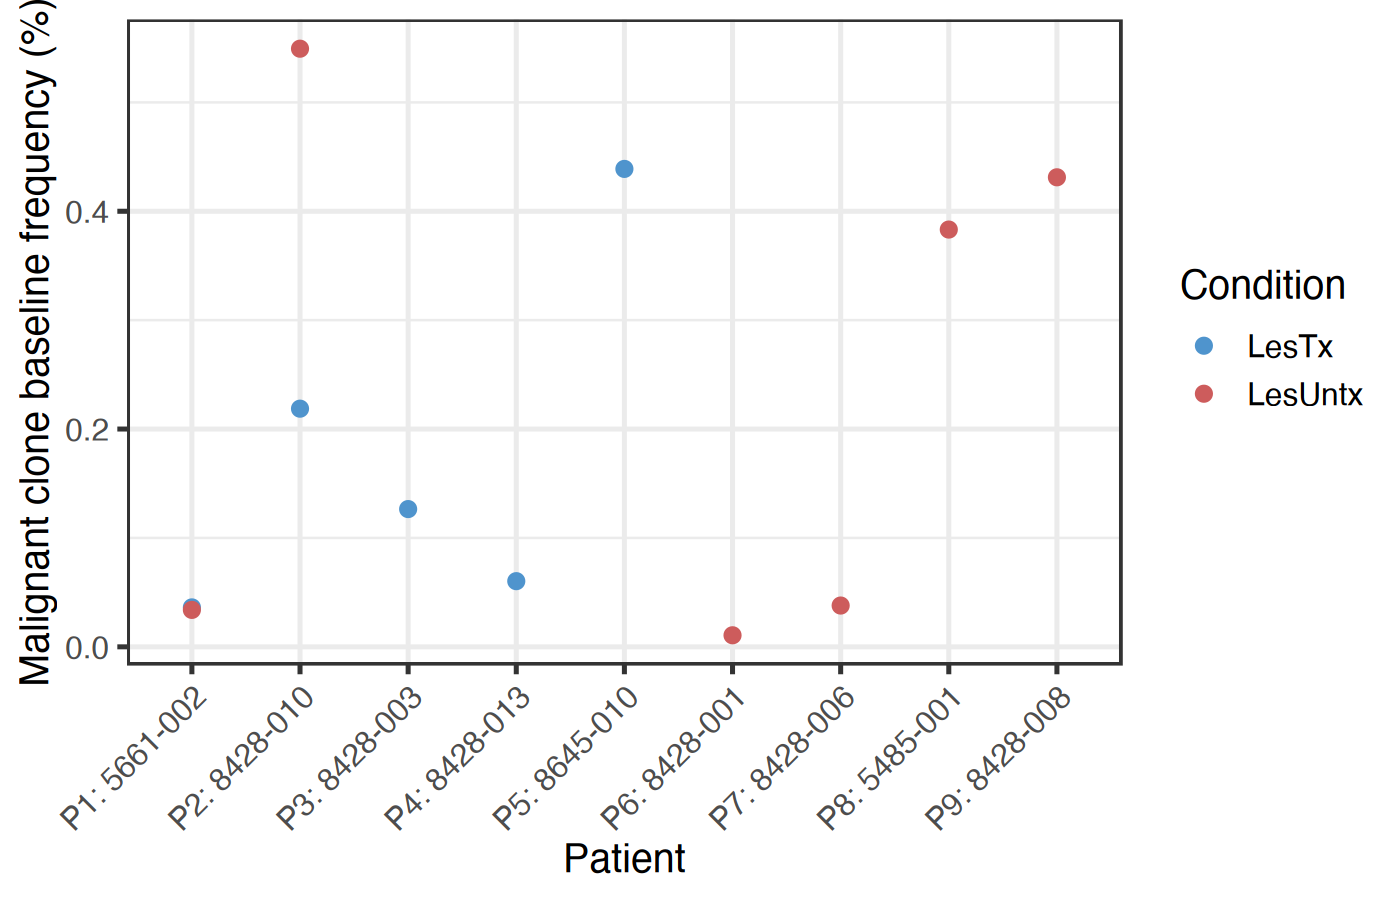

In [76]:
p = tcr_baseline_les %>% 
        ggplot(aes(x = paste(PatientID, Subject, sep = ": "), y = malig_percent, col = Condition)) +
        geom_point() +
        ylab('Malignant clone baseline frequency (%)') + xlab('Patient') +
        scale_color_manual(values = c('steelblue3', 'indianred')) + theme_bw(base_size=14) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
p

## Genomes/100ng DNA

Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_line()`).”
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


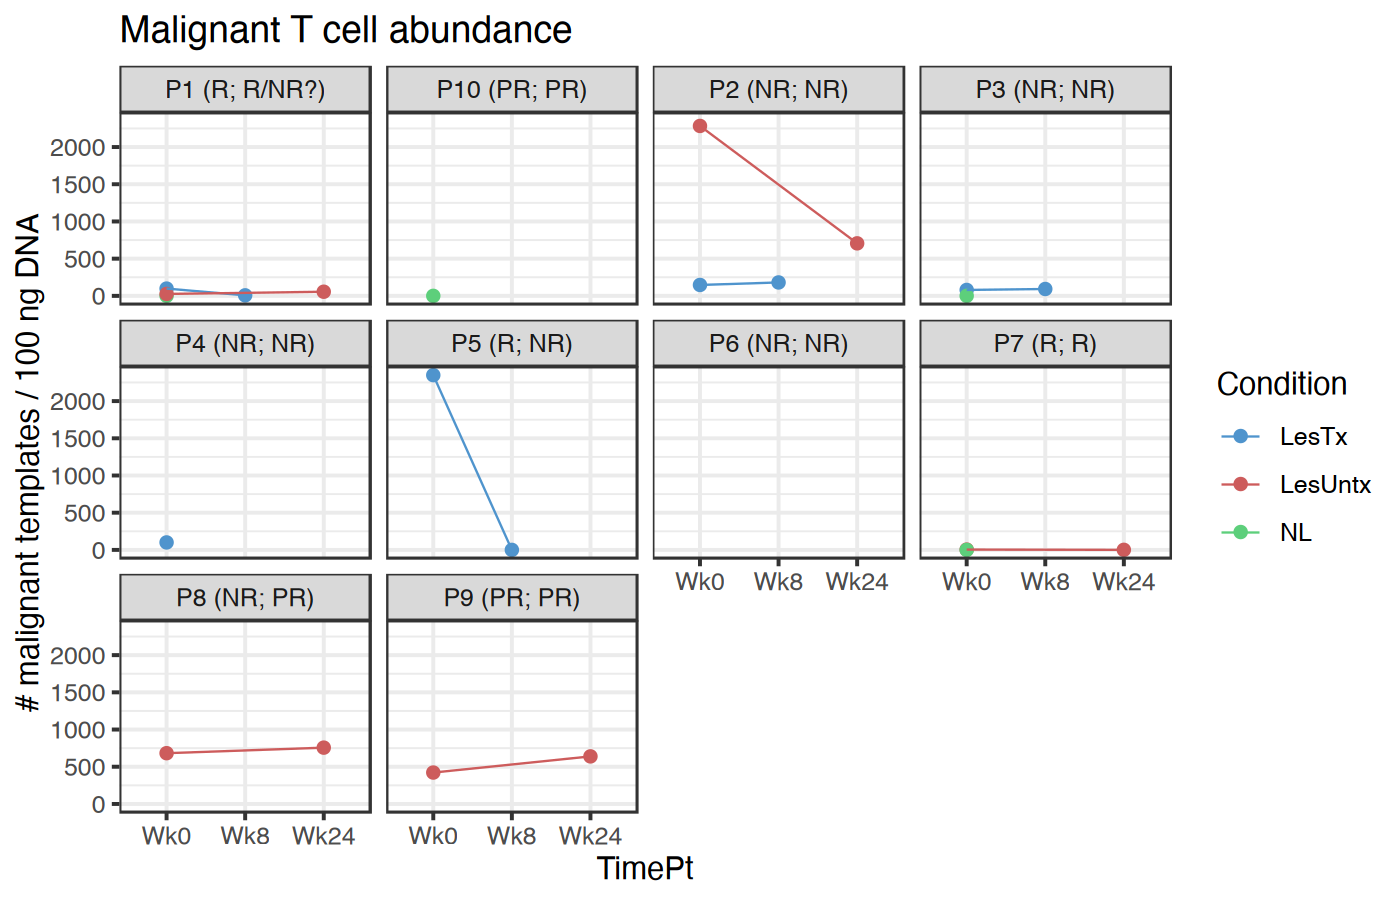

In [34]:
fig.size(4.5, 7)
p = tcr_data %>% 
        ggplot(aes(x = TimePt, y = Genomes.100ng.DNA...malig.templates.sample.amount..100., col = Condition)) +
        geom_point() +
        facet_wrap(~paste(PatientID, response_combined)) + theme_bw(base_size = 11) + 
        ylab('# malignant templates / 100 ng DNA') +
        expand_limits(y = 0) + ggtitle('Malignant T cell abundance') +
        scale_color_manual(values = c('steelblue3', 'indianred', '#5dcf7b')) +
        geom_line(aes(group = Condition), linewidth = 0.3)
p

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


agg_record_c394351335f 
                     2

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


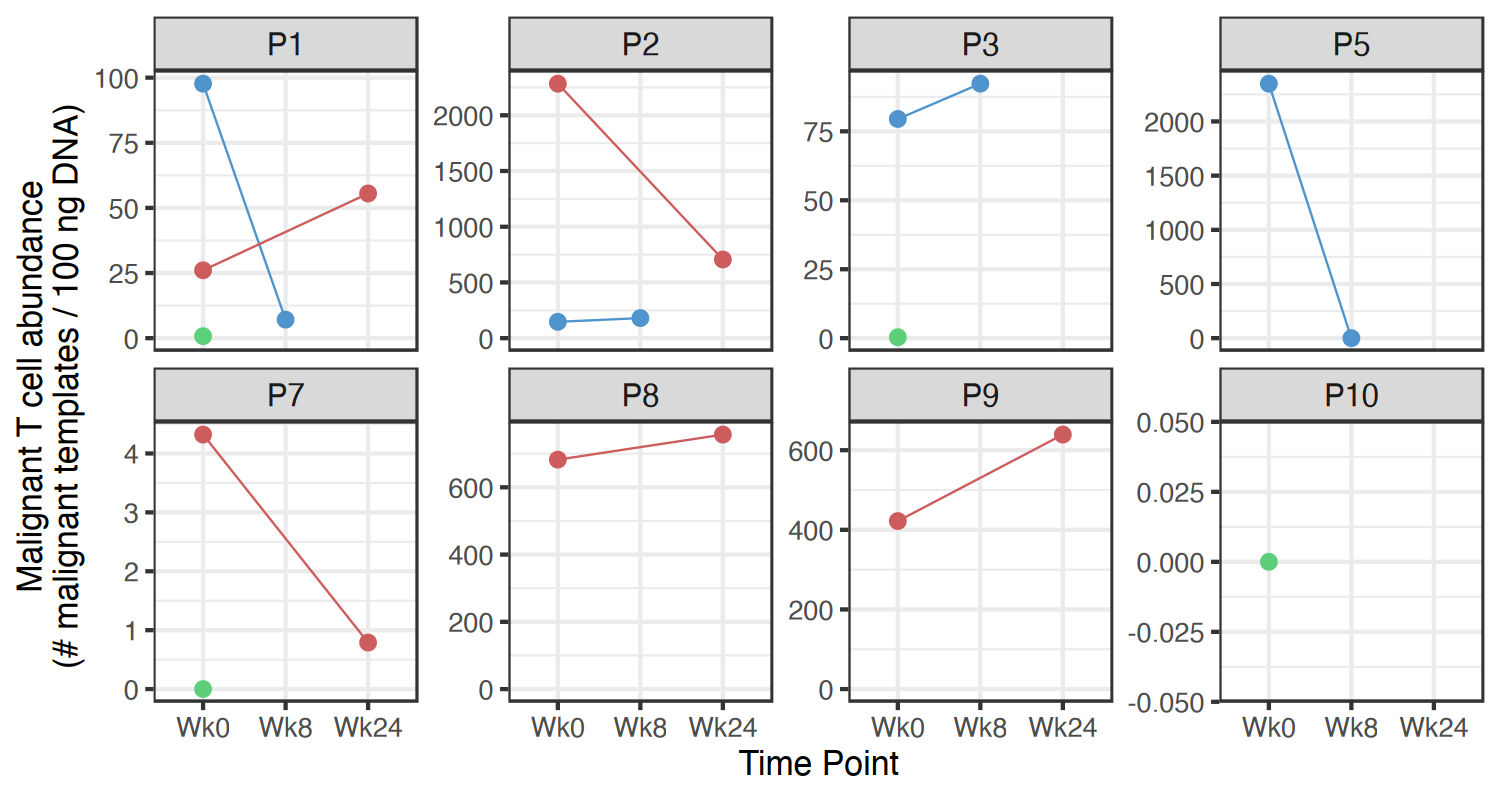

In [36]:
pdf('../_figures/Malignant_T_abundance.pdf', width = 7.5, height = 4)
fig.size(4, 7.5)
p = tcr_data %>% filter(Subject %in% c('8645-010', '5661-002', '8428-003', '8428-011',
                                       '8428-010', '5485-001', '8428-008', '8428-006')) %>%
        ggplot(aes(x = TimePt, 
                   y = Genomes.100ng.DNA...malig.templates.sample.amount..100., 
                   col = Condition)) +
        geom_point(size = 2) + labs(x = 'Time Point') +
        facet_wrap(~ PatientID, ncol = 4, scale = 'free_y') + theme_bw(base_size = 12) + 
        ylab('Malignant T cell abundance\n(# malignant templates / 100 ng DNA)') +
        expand_limits(y = 0) + theme(legend.position = 'none') +
        scale_color_manual(values = c('steelblue3', 'indianred', '#5dcf7b')) +
        geom_line(aes(group = Condition), linewidth = 0.3) +
        theme(strip.text = element_text(size = 11)) 
print(p)
dev.off()
p

## Malignant T cell frequency

Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_line()`).”
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


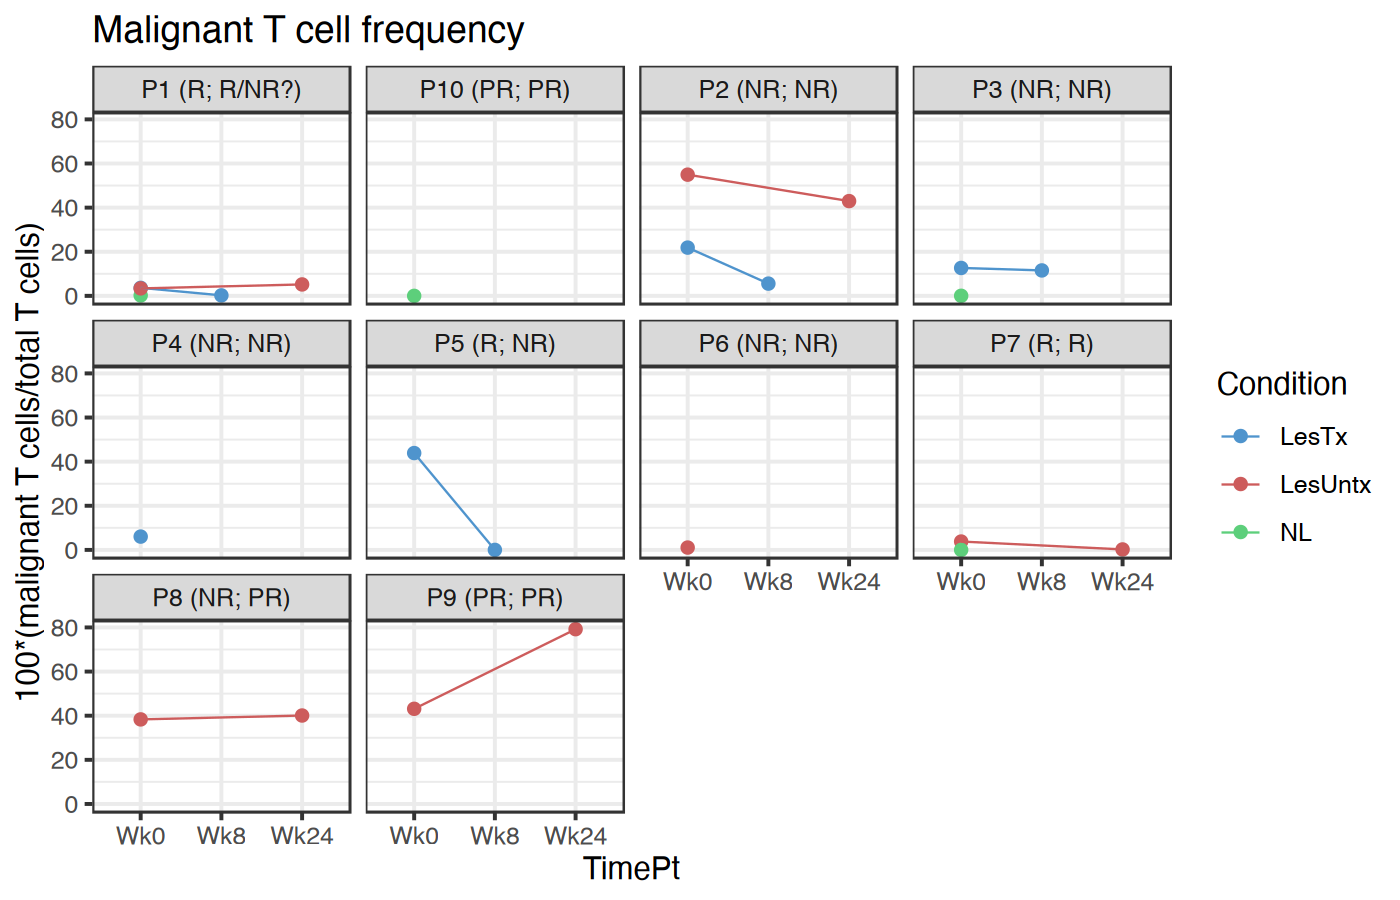

In [37]:
fig.size(4.5, 7)
tcr_data$Malig.clone.productive.frequency_num = as.numeric(str_sub(tcr_data$Malig.clone.productive.frequency, end = -2)) # remove '%'
p = tcr_data %>% ggplot(aes(x = TimePt, y = Malig.clone.productive.frequency_num, col = Condition)) +
                geom_point() +
                facet_wrap(~paste(PatientID, response_combined)) + theme_bw(base_size = 11) + ylab('100*(malignant T cells/total T cells)') +
                expand_limits(y = 0) + ggtitle('Malignant T cell frequency') +
                scale_color_manual(values = c('steelblue3', 'indianred', '#5dcf7b')) +
                geom_line(aes(group = Condition), linewidth = 0.3)
p

## % reduction in num of malignant T cells (using genomes/100ng)

In [12]:
# For untreated samples, calculate the percent clearance of malignant cells
# LesTx (Week 0 to Week 8)
tcr_data_lestx = tcr_data %>% filter(Condition == 'LesTx')

result_lestx = NULL
for (sub in unique(tcr_data_lestx$PatientID)) {
    if (! sub %in% c('P4')) { # did not have HTS for this sample
    wk0 = tcr_data_lestx[which(tcr_data_lestx$TimePt == 'Wk0' & tcr_data_lestx$PatientID == sub),
                         'Genomes.100ng.DNA...malig.templates.sample.amount..100.']
    wk8 = tcr_data_lestx[which(tcr_data_lestx$TimePt == 'Wk8' & tcr_data_lestx$PatientID == sub),
                         'Genomes.100ng.DNA...malig.templates.sample.amount..100.']
    pct_change_malig_clone = 100*((wk8-wk0)/wk0)
    change_malig_clone = wk8-wk0
    result_lestx = rbind(result_lestx, c(sub, change_malig_clone, pct_change_malig_clone)) }
}
result_lestx = as.data.frame(result_lestx)
colnames(result_lestx) = c('PatientID', 'Change_malig_clone', 'Pct_change_malig_clone')
result_lestx$Condition = 'LesTx_Wk0to8'

# For untreated samples, calculate the percent clearance of malignant cells
# LesUntx (Week 0 to Week 24)
tcr_data_lesuntx = tcr_data %>% filter(Condition == 'LesUntx')

result_lesuntx = NULL
for (sub in unique(tcr_data_lesuntx$PatientID)) {
    wk0 = tcr_data_lesuntx[which(tcr_data_lesuntx$TimePt == 'Wk0' & tcr_data_lesuntx$PatientID == sub),
                         'Genomes.100ng.DNA...malig.templates.sample.amount..100.']
    wk24 = tcr_data_lesuntx[which(tcr_data_lesuntx$TimePt == 'Wk24' & tcr_data_lesuntx$PatientID == sub),
                         'Genomes.100ng.DNA...malig.templates.sample.amount..100.']
    pct_change_malig_clone = 100*((wk24-wk0)/wk0)
    change_malig_clone = wk24-wk0
    result_lesuntx = rbind(result_lesuntx, c(sub, change_malig_clone, pct_change_malig_clone))
}
result_lesuntx = as.data.frame(result_lesuntx)
colnames(result_lesuntx) = c('PatientID', 'Change_malig_clone', 'Pct_change_malig_clone')
result_lesuntx$Condition = 'LesUntx_Wk0to24'

result = rbind(result_lestx, result_lesuntx)
result$Change_malig_clone = as.numeric(result$Change_malig_clone)
result$Pct_change_malig_clone = as.numeric(result$Pct_change_malig_clone)

In [13]:
# order the bars by increasing result_lestx$Pct_change_malig_clone
result_lestx$Pct_change_malig_clone = as.numeric(result_lestx$Pct_change_malig_clone)
order(result_lestx$Pct_change_malig_clone)

result$PatientID = factor(result$PatientID, 
            levels = c(result_lestx$PatientID[order(result_lestx$Pct_change_malig_clone)], 
                       'P7', 'P8', 'P9'))

[1] 4 1 2 3

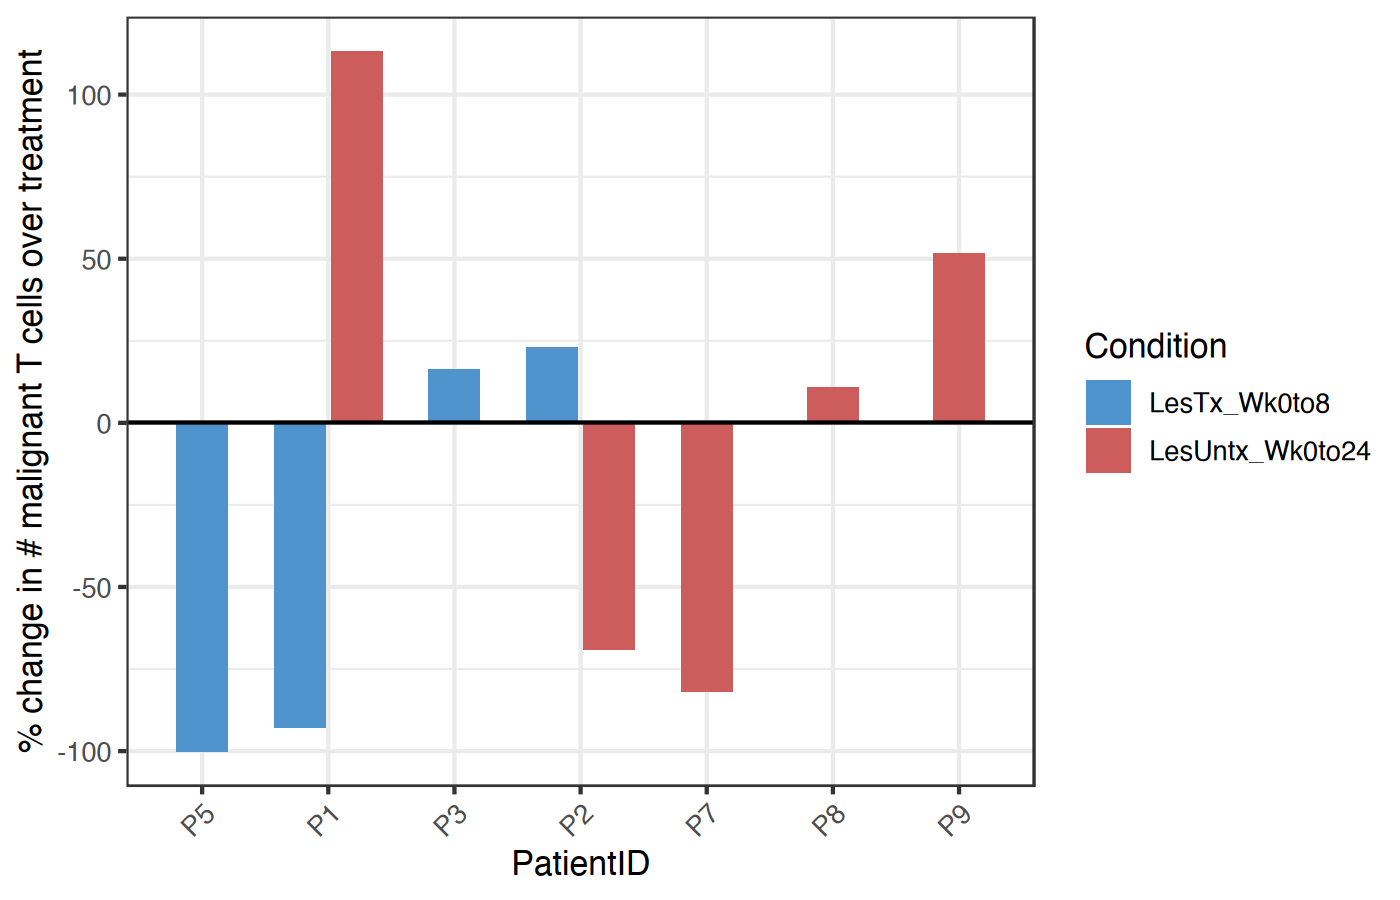

In [14]:
result %>%
    ggplot(aes(x = PatientID, y = Pct_change_malig_clone, fill = Condition)) +
        geom_bar(stat = "identity", position = position_dodge2(width = 0.9, preserve = "single")) + 
        theme_bw(base_size = 12) + scale_fill_manual(values = c('steelblue3', 'indianred')) +
        theme(axis.text.x = element_text(angle = 45, hjust=1)) +
        ylab('% change in # malignant T cells over treatment') +
        geom_hline(yintercept = 0)

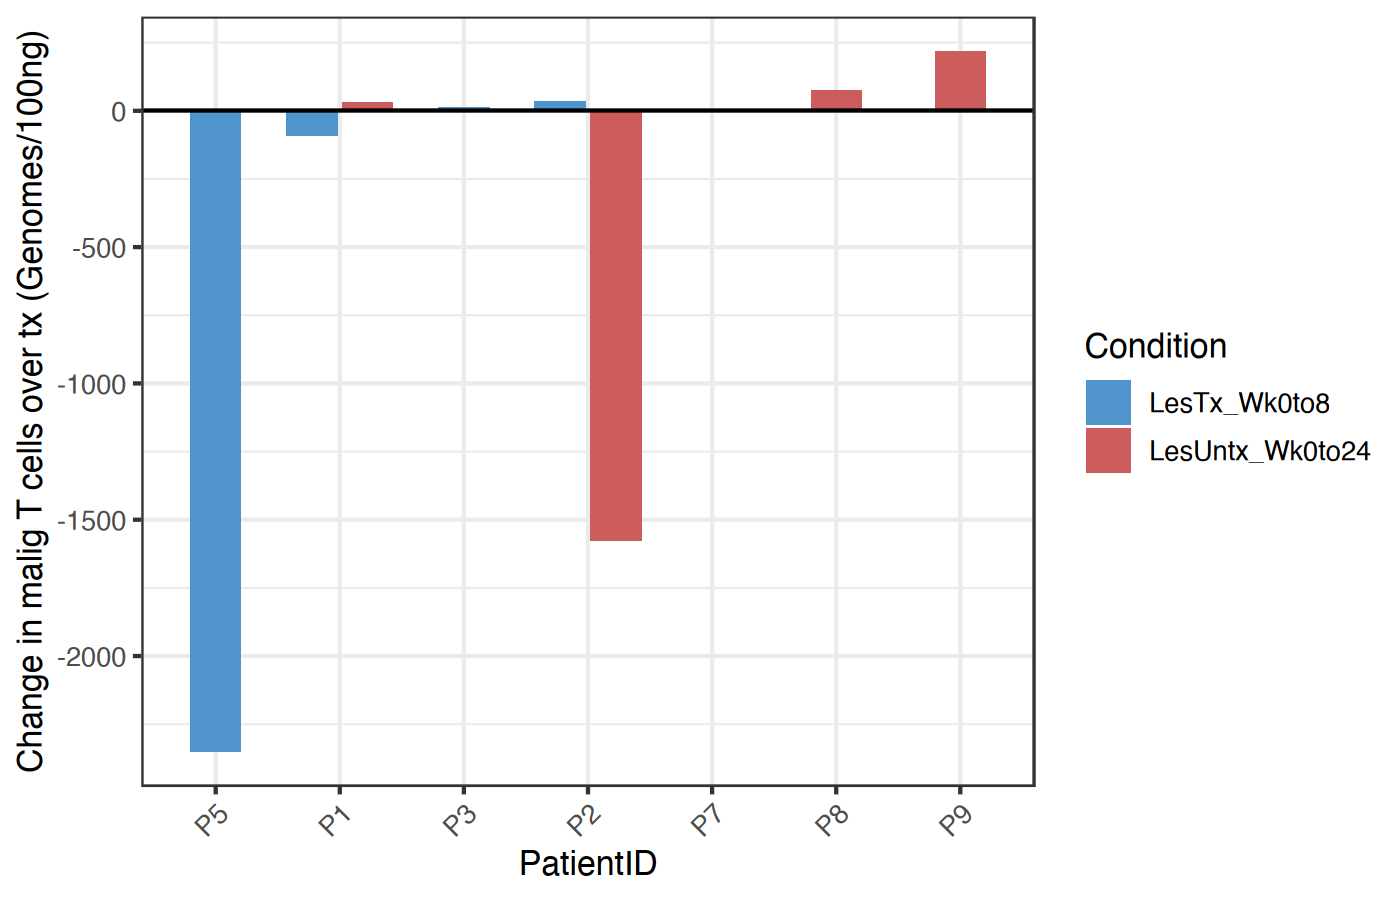

In [15]:
# order the bars by increasing result_lesuntx$Change_malig_clone
result %>%
    ggplot(aes(x = PatientID, y = Change_malig_clone, fill = Condition)) +
        geom_bar(stat = "identity", position = position_dodge2(width = 0.9, preserve = "single")) + 
        theme_bw(base_size = 12) + scale_fill_manual(values = c('steelblue3', 'indianred')) +
        theme(axis.text.x = element_text(angle = 45, hjust=1)) +
        ylab('Change in malig T cells over tx (Genomes/100ng)') +
        geom_hline(yintercept = 0)

In [16]:
result = result %>% mutate(
    Condition = ifelse(Condition == 'LesTx_Wk0to8', 'Treated Lesional (Wk 0 to 8)',
                                     'Untreated Lesional (Wk 0 to 24)'))

In [17]:
result_Tx = result %>% filter(Condition == 'Treated Lesional (Wk 0 to 8)') %>%
                       mutate(PatientID = reorder(PatientID, Pct_change_malig_clone))
result_Untx = result %>% filter(Condition != 'Treated Lesional (Wk 0 to 8)') %>%
                       mutate(PatientID = reorder(PatientID, Pct_change_malig_clone))

In [18]:
result

PatientID,Change_malig_clone,Pct_change_malig_clone,Condition
<fct>,<dbl>,<dbl>,<chr>
P1,-90.580925,-92.71801,Treated Lesional (Wk 0 to 8)
P3,12.803091,16.10836,Treated Lesional (Wk 0 to 8)
P2,33.658869,22.93729,Treated Lesional (Wk 0 to 8)
P5,-2348.644425,-100.00000,Treated Lesional (Wk 0 to 8)
P8,74.489043,10.91828,Untreated Lesional (Wk 0 to 24)
P1,29.476250,113.10573,Untreated Lesional (Wk 0 to 24)
P7,-3.530927,-81.72370,Untreated Lesional (Wk 0 to 24)
P9,217.251251,51.47950,Untreated Lesional (Wk 0 to 24)
P2,-1577.832952,-69.09332,Untreated Lesional (Wk 0 to 24)


agg_record_43bf3c10e9ce 
                      2

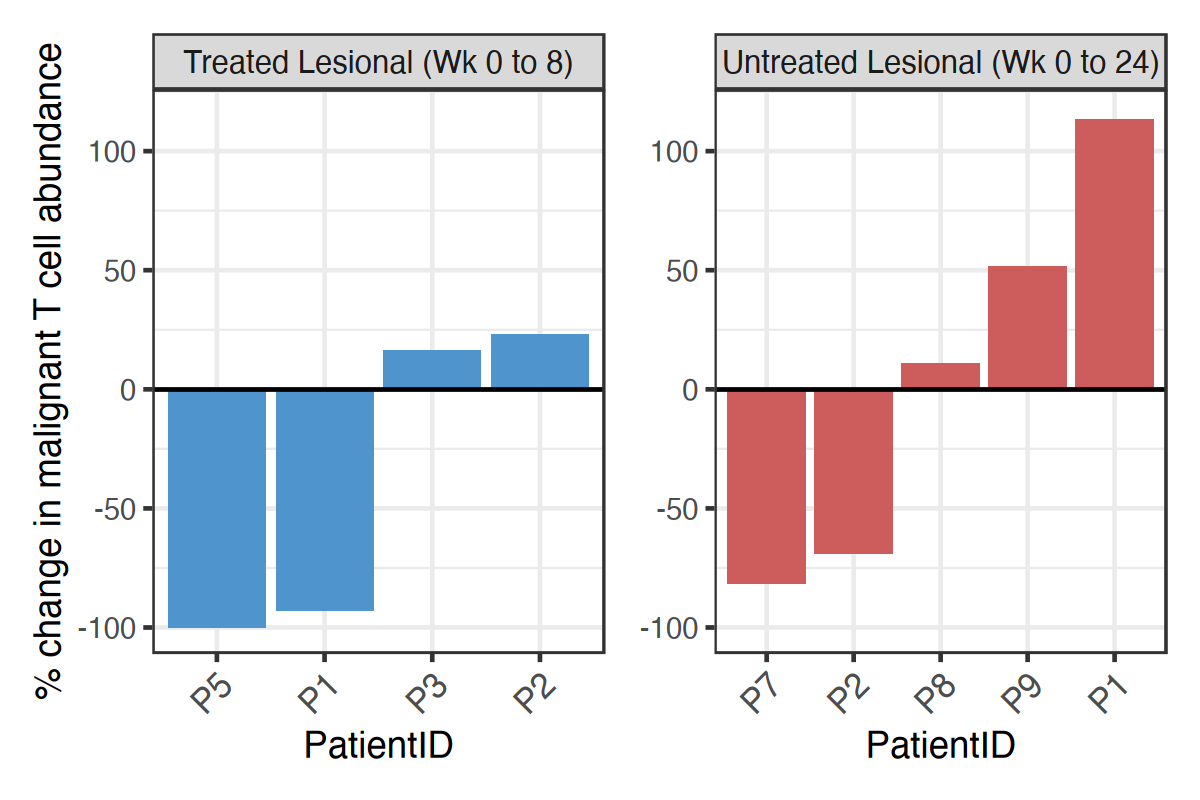

In [19]:
fig.size(4, 6)
pdf('../_figures/TCR_percent_change.pdf', width = 6, height = 4)
p_Tx = result_Tx %>%
    ggplot(aes(x = PatientID, y = Pct_change_malig_clone, fill = Condition)) +
        geom_bar(stat = "identity", position = position_dodge2(width = 0.9, preserve = "single")) + 
        theme_bw(base_size = 13) + scale_fill_manual(values = c('steelblue3')) +
        theme(axis.text.x = element_text(angle = 45, hjust=1)) +
        ylab('% change in malignant T cell abundance') +
        geom_hline(yintercept = 0) + facet_wrap(~Condition, ncol = 2, scale = 'free_x') + 
        theme(legend.position = 'none', strip.text.x = element_text(size = 11)) +
        ylim(-100, 115) + theme(axis.text.x = element_text(size = 12))
p_Untx = result_Untx %>%
    ggplot(aes(x = PatientID, y = Pct_change_malig_clone, fill = Condition)) +
        geom_bar(stat = "identity", position = position_dodge2(width = 0.9, preserve = "single")) + 
        theme_bw(base_size = 13) + scale_fill_manual(values = c('indianred')) +
        theme(axis.text.x = element_text(angle = 45, hjust=1)) +
        labs(y = NULL) +
        geom_hline(yintercept = 0) + facet_wrap(~Condition, ncol = 2, scale = 'free_x') + 
        theme(legend.position = 'none', strip.text.x = element_text(size = 11)) + 
        ylim(-100, 115) + theme(axis.text.x = element_text(size = 12))
print(p_Tx | p_Untx)
dev.off()
p_Tx | p_Untx

## Export TCR data

In [21]:
write.csv(result_lesuntx, '../_results/tcr/result_lesuntx.csv', quote = F, row.names = F)
write.csv(result_lestx, '../_results/tcr/result_lestx.csv', quote = F, row.names = F)

In [22]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20.0.0
Running under: macOS Sonoma 14.6

Matrix products: default
BLAS/LAPACK: /opt/anaconda3/envs/resiq/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] org.Hs.eg.db_3.20.0         AnnotationDbi_1.68.0       
 [3] msigdbr_26.1.0              clusterProfiler_4.14.0     
 [5] rlang_1.2.0                 scales_1.4.0               
 [7] patchwork_1.3.2             RColorBrewer_1.1-3         
 [9] rstatix_0.7.3               mixtools_2.0.0.1           
[11] limma_3.62.2                cowplot_1.2.0              
[13] ggrastr_1.0.2               ggpubr_0.6.3               
[15] lme4_2.0-1                  singlecellmethods_0.1.0    
[17] MAST_1.32.0           